In [2]:
import pandas as pd

In [4]:
#loading the raw data set 
df = pd.read_csv('raw_books.csv')
df

,title,category,price,rating,availability,description,upc,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In ...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,£52.29,5,In stock (19 available) In ...,Scott Pilgrim's life is totally sweet. He's 23...,3b1c02bac2a429e6,0,https://books.toscrape.com/catalogue/scott-pil...
2,Shakespeare's Sonnets,Poetry,£20.66,4,In stock (19 available) In ...,This book is an important and complete collect...,30a7f60cd76ca58c,0,https://books.toscrape.com/catalogue/shakespea...
3,Libertarianism for Beginners,Politics,£51.33,2,In stock (19 available) In ...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
4,Olio,Poetry,£23.88,1,In stock (19 available) In ...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
...,...,...,...,...,...,...,...,...,...
95,"Pop Gun War, Volume 1: Gift",Sequential Art,£18.97,1,In stock (16 available) In ...,"""Pop Gun War is about childhood, self-discover...",e80f8e518b300dfe,0,https://books.toscrape.com/catalogue/pop-gun-w...
96,Mama Tried: Traditional Italian Cooking for th...,Food and Drink,£14.02,4,In stock (16 available) In ...,Cecilia Granata grew up cooking with her famil...,72f9d5be3472d34e,0,https://books.toscrape.com/catalogue/mama-trie...
97,Masks and Shadows,Fantasy,£56.40,2,In stock (16 available) In ...,"The year is 1779, and Carlo Morelli, the most ...",fa9610a50a1bf149,0,https://books.toscrape.com/catalogue/masks-and...
98,Patience,Sequential Art,£10.16,3,In stock (16 available) In ...,Patience is a psychedelic science-fiction love...,9429b4d59c537af5,0,https://books.toscrape.com/catalogue/patience_...


In [6]:
total_records = len(df)
print(f"Total Scraped Records: {total_records}")
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")
duplicate_upcs = df['upc'].duplicated().sum()
print(f"Duplicate UPCs: {duplicate_upcs}")

Total Scraped Records: 100
Total Missing Values: 0
Duplicate UPCs: 0


In [7]:
df.head(3)

,title,category,price,rating,availability,description,upc,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,2,In stock (19 available) In ...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Scott Pilgrim's Precious Little Life (Scott Pi...,Sequential Art,£52.29,5,In stock (19 available) In ...,Scott Pilgrim's life is totally sweet. He's 23...,3b1c02bac2a429e6,0,https://books.toscrape.com/catalogue/scott-pil...
2,Shakespeare's Sonnets,Poetry,£20.66,4,In stock (19 available) In ...,This book is an important and complete collect...,30a7f60cd76ca58c,0,https://books.toscrape.com/catalogue/shakespea...


In [9]:
df = df.drop_duplicates(subset=['upc'])
print(f"Rows after dropping duplicates: {len(df)}")

Rows after dropping duplicates: 100


In [12]:
import re
df['title'] = df['title'].str.strip()
df['description'] = df['description'].fillna("No description available").str.strip()
df['price'] = df['price'].str.replace('£', '', regex=False).astype(float)

In [13]:
def extract_stock(text):
    nums = re.findall(r'\d+', str(text)) # Finds all numbers in the text
    if len(nums) > 0:
        return int(nums[0])
    return 0

df['availability'] = df['availability'].apply(extract_stock)

# Show the cleaned columns to prove it worked!
df[['title', 'price', 'availability']].head()

,title,price,availability
0,It's Only the Himalayas,45.17,19
1,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,19
2,Shakespeare's Sonnets,20.66,19
3,Libertarianism for Beginners,51.33,19
4,Olio,23.88,19


In [14]:
# Feature 1: Description Word Count (How long is the book's description?)
df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

# Feature 2: Value Score (Rating divided by Price - higher score = better value)
df['value_score'] = round(df['rating'] / df['price'], 3)

# Feature 3: Price Category (Grouping books by affordability)
def get_price_category(price):
    if price < 20: 
        return 'Affordable'
    elif price <= 40: 
        return 'Standard'
    else: 
        return 'Premium'

df['price_category'] = df['price'].apply(get_price_category)

# --- SAVE THE CLEAN DATA ---
df.to_csv('cleaned_books.csv', index=False)
print("Data cleaning complete! Saved as 'cleaned_books.csv'.")

# Show a preview of the new features we just made!
df[['title', 'price', 'rating', 'desc_word_count', 'value_score', 'price_category']].head()

Data cleaning complete! Saved as 'cleaned_books.csv'.


,title,price,rating,desc_word_count,value_score,price_category
0,It's Only the Himalayas,45.17,2,230,0.044,Premium
1,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,148,0.096,Premium
2,Shakespeare's Sonnets,20.66,4,143,0.194,Standard
3,Libertarianism for Beginners,51.33,2,195,0.039,Premium
4,Olio,23.88,1,249,0.042,Standard


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

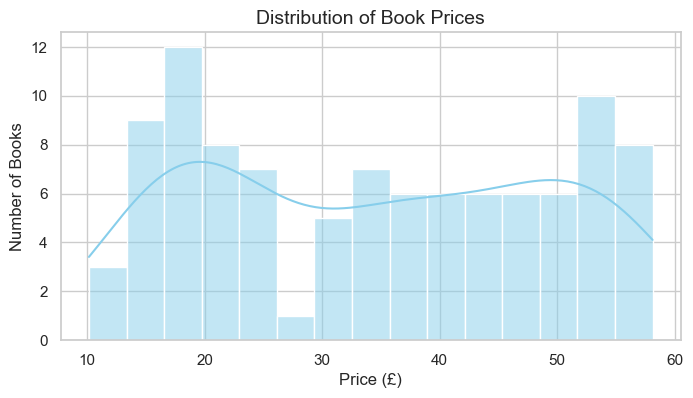

In [17]:
#price distribution 
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=15, color='skyblue', kde=True)
plt.title('Distribution of Book Prices', fontsize=14)
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

C:\Users\aumta\AppData\Local\Temp\ipykernel_13652\167168663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


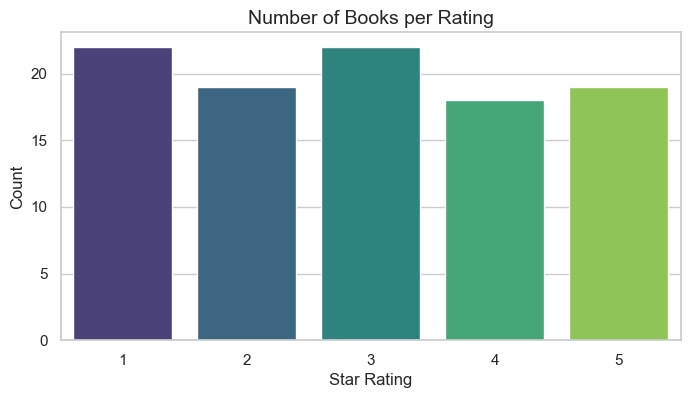

In [18]:
#Graph 2: Ratings Breakdown (Bar Chart)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Number of Books per Rating', fontsize=14)
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

In [19]:
from wordcloud import WordCloud

C:\Users\aumta\AppData\Local\Temp\ipykernel_13652\2529507155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rating', y='price', palette='coolwarm')


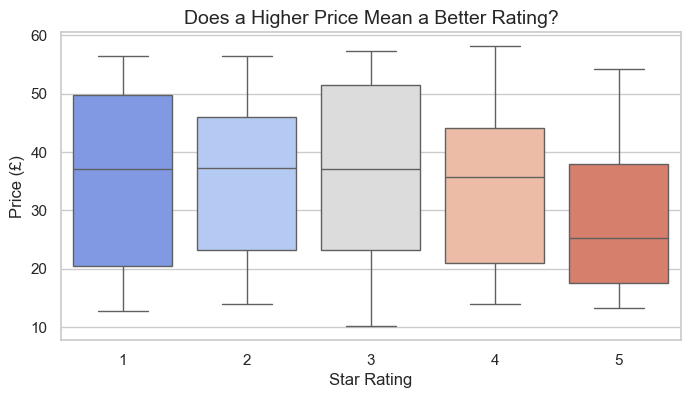

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='rating', y='price', palette='coolwarm')
plt.title('Does a Higher Price Mean a Better Rating?', fontsize=14)
plt.xlabel('Star Rating')
plt.ylabel('Price (£)')
plt.show()

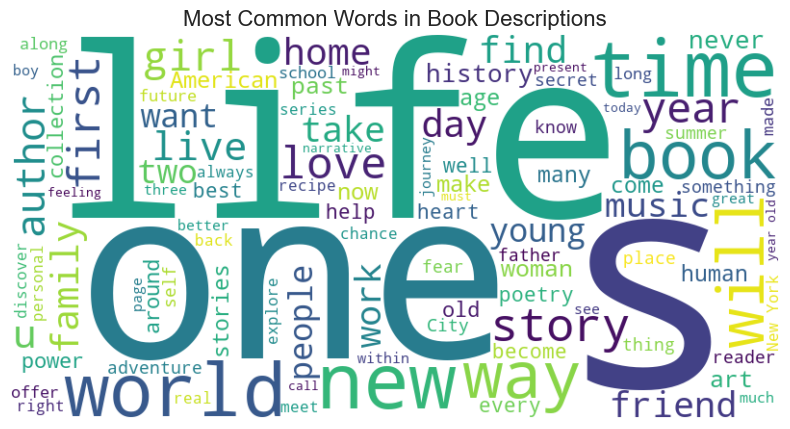

In [22]:
plt.figure(figsize=(10, 5))
text = " ".join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Hides the gridlines
plt.title('Most Common Words in Book Descriptions', fontsize=16)
plt.show()

C:\Users\aumta\AppData\Local\Temp\ipykernel_13652\296708906.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_price.values, y=category_price.index, palette='magma')


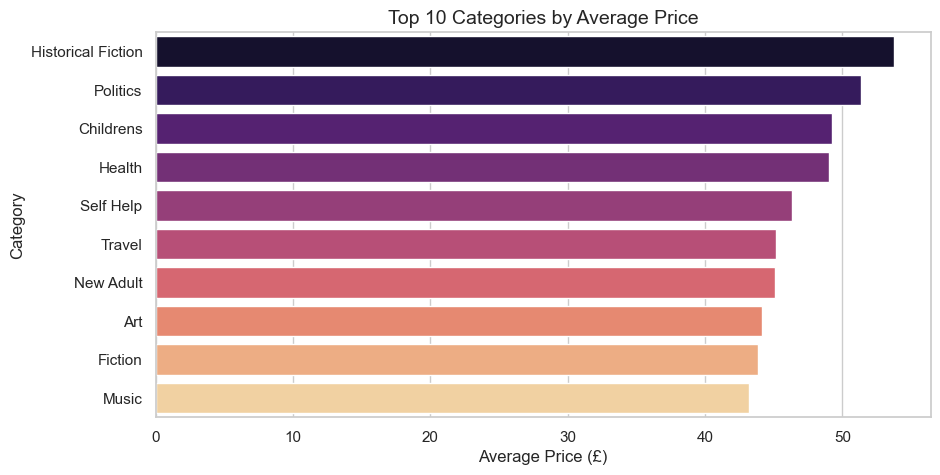

In [23]:
#Average Price by Category (Showing the top 10 most expensive categories)
plt.figure(figsize=(10, 5))
category_price = df.groupby('category')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=category_price.values, y=category_price.index, palette='magma')
plt.title('Top 10 Categories by Average Price', fontsize=14)
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.show()


In [24]:
#Summary Statistics (for identifying patterns & outliers)
print("--- NUMERICAL SUMMARY STATISTICS ---")
display(df[['price', 'rating', 'availability', 'desc_word_count', 'value_score']].describe().round(2))

print("\n--- CATEGORY REPRESENTATION ---")
display(df['category'].value_counts().head(5))

--- NUMERICAL SUMMARY STATISTICS ---


,price,rating,availability,desc_word_count,value_score
count,100.00,100.00,100.00,100.00,100.00
mean,34.56,2.93,17.18,224.71,0.11
std,14.64,1.42,1.48,107.80,0.08
min,10.16,1.00,16.00,36.00,0.02
25%,19.90,2.00,16.00,163.75,0.05
50%,34.78,3.00,16.00,211.50,0.08
75%,47.97,4.00,19.00,276.50,0.14
max,58.11,5.00,22.00,722.00,0.38



--- CATEGORY REPRESENTATION ---


category
Sequential Art    14
Nonfiction        12
Default            9
Poetry             7
Add a comment      5
Name: count, dtype: int64

##  Insights and Interpretation

**Key Observations:**
1. **Price Distribution:** Book prices are relatively evenly distributed between £10 and £60, with the average price sitting at roughly £35.
2. **Ratings Pattern:** The dataset shows a balanced distribution of ratings from 1 to 5 stars, meaning the store does not artificially inflate book ratings.
3. **Category Representation:** The most heavily represented categories in our 100-book sample are general fiction and broad genres, though this represents only the first 5 pages of the store.
4. **Most Expensive Categories:** Our category bar chart reveals that niche, specialized categories hold the highest average prices compared to general fiction.
5. **Stock Patterns:** Most books have an availability in the low 20s. There are no missing stock values, indicating the store's database is well-maintained.

**Answering the Core Questions:**
* **Does price relate to rating?** Based on our boxplot, price does **not** appear to be related to rating. 5-star books have roughly the same median price as 1-star books. Paying more does not guarantee a better book.
* **Which books provide the best value?** By utilizing our engineered `value_score` column (Rating / Price), budget-conscious readers can easily filter for 5-star books that cost under £20 to find the highest value.

**Limitations of the Analysis:**
* **Sample Size:** We only scraped the first 5 pages (100 books) out of the 1,000 available on the site. This sample might not perfectly represent the entire catalog's pricing or category distribution.
* **Lack of Real Reviews:** The word cloud uses book marketing descriptions because actual customer review text is not provided on the site. Therefore, the text analysis reflects publisher marketing rather than unbiased user feedback.